In [1]:
from elos import EloTracker
from utils import load_all_games_csv, get_teams, predict_lr_use_pitchers_if_first_games
from simulation import MLBSimulator, uniform_simulation, pa_simulation
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

# Simulation

This notebook focuses on simulating a given season via Elo ratings ratings, estimating each team's probability of making it to the playoffs and different rounds within them.

It then calculates the r^2 between actual and predicted wins for the season.

In [2]:
season = 2024

## Get Divisions and Leagues for Teams

In [3]:
# Get divisions and leagues for each team
AL_EAST = {'TOR', 'NYA', 'BOS', 'TBA', 'BAL'}
AL_CENTRAL = {'CLE', 'DET', 'KCA', 'MIN', 'CHA'}
AL_WEST = {'SEA', 'HOU', 'TEX', 'OAK', 'ANA'}
#AL_WEST = {'SEA', 'HOU', 'TEX', 'ATH', 'ANA'}
AL = [AL_EAST, AL_CENTRAL, AL_WEST]

NL_EAST = {'PHI', 'NYN', 'MIA', 'ATL', 'WAS'}
NL_CENTRAL = {'MIL', 'CHN', 'CIN', 'SLN', 'PIT'}
NL_WEST = {'LAN', 'SDN', 'SFN', 'ARI', 'COL'}

NL = NL_EAST, NL_CENTRAL, NL_WEST

TEAMS = AL_EAST | AL_CENTRAL | AL_WEST | NL_EAST | NL_CENTRAL | NL_WEST
TEAMS

{'ANA',
 'ARI',
 'ATL',
 'BAL',
 'BOS',
 'CHA',
 'CHN',
 'CIN',
 'CLE',
 'COL',
 'DET',
 'HOU',
 'KCA',
 'LAN',
 'MIA',
 'MIL',
 'MIN',
 'NYA',
 'NYN',
 'OAK',
 'PHI',
 'PIT',
 'SDN',
 'SEA',
 'SFN',
 'SLN',
 'TBA',
 'TEX',
 'TOR',
 'WAS'}

## Get Elo Ratings for each team

In [4]:
all_games = load_all_games_csv(preprocess=True)
games_before = all_games[all_games['season'] < season] # Up to season

teams = get_teams(games_before)
et = EloTracker()

et.add_history(games_before)

# Get dict of latest elos for teams
elos_map = {team: et.elos_map[team][0] for team in TEAMS}
#elos_map = {team: et.elos_map[team][0] for team in (TEAMS | {'OAK'}) - {'ATH'}}
#elos_map['ATH'] = et.elos_map['OAK'][0]

# Revert to mean by 1/3 for new season
elos_map = {team: elos_map[team] + (1500 - elos_map[team]) / 3 for team in TEAMS}

elos_map

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/misc_utils.py:48: DtypeWarning: Columns (10,11,13,17,19,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  all_games = pd.read_csv(clean_data_dir / filename)


{'SLN': 1492.0994755338897,
 'TEX': 1510.6529674541089,
 'CHA': 1468.4880972464805,
 'TBA': 1528.3126977956285,
 'DET': 1487.5559674456192,
 'CIN': 1491.3733171978079,
 'PHI': 1521.640278236941,
 'CHN': 1498.3528098808254,
 'PIT': 1480.1079422986888,
 'ANA': 1481.0687816999978,
 'COL': 1461.7172956067143,
 'MIL': 1517.731431712836,
 'MIN': 1504.962931501618,
 'SFN': 1498.6255868438323,
 'MIA': 1494.805750852906,
 'TOR': 1517.302890489182,
 'ARI': 1500.8237056084765,
 'KCA': 1457.906435190479,
 'LAN': 1543.4107631705908,
 'HOU': 1528.3503870057548,
 'BOS': 1495.1440924651886,
 'NYN': 1499.0203088917795,
 'OAK': 1450.9709734447,
 'CLE': 1497.2876719054068,
 'SEA': 1516.6174132642636,
 'ATL': 1541.6412822013108,
 'WAS': 1473.4180148940052,
 'SDN': 1507.0774473180734,
 'BAL': 1523.357162336001,
 'NYA': 1510.2980911635152}

## Get Schedule

In [5]:
schedule_df = all_games[(all_games['season'] == season) & (all_games['gametype'] == 'regular')]
schedule_df.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,vispitcherminusteamrgs,homefirstpitchergameofseason,visfirstpitchergameofseason,homelastkwinpct,vislastkwinpct,adjustedvisrestdays,adjustedhomerestdays,adjustedhomedistancetraveled,adjustedvisdistancetraveled,adjustedmarginofvictory
gid,,,,,,,,,,,,,,,,,,,,,
SDN202403200,LAN,SDN,SEO01,20240320,0.0,7:05PM,night,9.0,2.0,True,...,4.938384,True,True,NaN,NaN,3.0,3.0,18.161201,0.000000,1.732051
LAN202403210,SDN,LAN,SEO01,20240321,0.0,7:05PM,night,9.0,2.0,True,...,0.543137,True,True,1.0,0.0,1.0,1.0,0.000000,0.000000,2.000000
ARI202403280,COL,ARI,PHO01,20240328,0.0,7:10PM,night,9.0,2.0,True,...,0.824819,True,True,NaN,NaN,3.0,3.0,0.000000,8.368860,3.872983
BAL202403280,ANA,BAL,BAL12,20240328,0.0,3:05PM,day,9.0,2.0,True,...,-1.430923,True,True,NaN,NaN,3.0,3.0,0.000000,13.202777,2.828427
CHA202403280,DET,CHA,CHI12,20240328,0.0,3:10PM,day,9.0,2.0,True,...,6.858436,True,True,NaN,NaN,3.0,3.0,0.000000,6.194582,1.000000


## Simulate Seasons

In [6]:
sim = MLBSimulator(schedule_df, AL, NL, season, elos_map, simulation_func=pa_simulation)
sim.simulate_seasons(100)
team_results = sim.team_results

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/misc_utils.py:156: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,44,46,61,63,99,110) have mixed types. Specify dtype option on import or set low_memory=False.
  team_stats = pd.read_csv(clean_data_dir / "teamstats_clean.csv")
/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/misc_utils.py:79: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  batting = pd.read_csv(clean_data_dir / filename)
  0%|          | 0/100 [00:00<?, ?it/s]

Home: 1.0; Away: 8.0
Home: 7.0; Away: 2.0
Home: 4.0; Away: 0.0
Home: 0.0; Away: 5.0
Home: 3.0; Away: 4.0
Home: 6.0; Away: 3.0
Home: 2.0; Away: 3.0
Home: 5.0; Away: 2.0
Home: 15.0; Away: 0.0
Home: 5.0; Away: 2.0
Home: 6.0; Away: 1.0
Home: 11.0; Away: 1.0
Home: 6.0; Away: 3.0
Home: 3.0; Away: 9.0
Home: 5.0; Away: 2.0
Home: 2.0; Away: 6.0
Home: 3.0; Away: 5.0
Home: 6.0; Away: 1.0
Home: 7.0; Away: 0.0
Home: 2.0; Away: 1.0
Home: 6.0; Away: 2.0
Home: 8.0; Away: 2.0
Home: 13.0; Away: 3.0
Home: 4.0; Away: 7.0
Home: 7.0; Away: 10.0
Home: 6.0; Away: 5.0
Home: 3.0; Away: 6.0
Home: 4.0; Away: 6.0
Home: 3.0; Away: 1.0
Home: 4.0; Away: 7.0
Home: 0.0; Away: 7.0
Home: 7.0; Away: 2.0
Home: 2.0; Away: 4.0
Home: 1.0; Away: 0.0
Home: 1.0; Away: 4.0
Home: 12.0; Away: 7.0
Home: 3.0; Away: 6.0
Home: 0.0; Away: 3.0
Home: 9.0; Away: 2.0
Home: 12.0; Away: 3.0
Home: 5.0; Away: 0.0
Home: 2.0; Away: 11.0
Home: 3.0; Away: 1.0
Home: 4.0; Away: 2.0
Home: 2.0; Away: 5.0
Home: 1.0; Away: 10.0
Home: 9.0; Away: 6.0
Home:

  1%|          | 1/100 [00:01<02:29,  1.51s/it]

Home: 0.0; Away: 4.0
Home: 5.0; Away: 1.0
Home: 4.0; Away: 0.0
Home: 2.0; Away: 10.0
Home: 1.0; Away: 0.0
Home: 3.0; Away: 0.0
Home: 7.0; Away: 2.0
Home: 3.0; Away: 5.0
Home: 4.0; Away: 5.0
Home: 4.0; Away: 15.0
Home: 3.0; Away: 0.0
Home: 4.0; Away: 5.0
Home: 7.0; Away: 2.0
Home: 0.0; Away: 1.0
Home: 4.0; Away: 1.0
Home: 3.0; Away: 8.0
Home: 7.0; Away: 4.0
Home: 3.0; Away: 7.0
Home: 1.0; Away: 5.0
Home: 8.0; Away: 1.0
Home: 0.0; Away: 3.0
Home: 2.0; Away: 8.0
Home: 2.0; Away: 4.0
Home: 4.0; Away: 1.0
Home: 1.0; Away: 8.0
Home: 2.0; Away: 1.0
Home: 1.0; Away: 13.0
Home: 6.0; Away: 5.0
Home: 8.0; Away: 2.0
Home: 4.0; Away: 9.0
Home: 5.0; Away: 10.0
Home: 4.0; Away: 5.0
Home: 1.0; Away: 5.0
Home: 0.0; Away: 1.0
Home: 1.0; Away: 3.0
Home: 2.0; Away: 5.0
Home: 6.0; Away: 10.0
Home: 5.0; Away: 7.0
Home: 4.0; Away: 2.0
Home: 3.0; Away: 0.0
Home: 6.0; Away: 2.0
Home: 8.0; Away: 2.0
Home: 2.0; Away: 3.0
Home: 15.0; Away: 7.0
Home: 4.0; Away: 5.0
Home: 2.0; Away: 3.0
Home: 3.0; Away: 1.0
Home: 8

  2%|▏         | 2/100 [00:03<02:29,  1.53s/it]

...

 23%|██▎       | 23/100 [00:32<01:48,  1.42s/it]

Home: 4.0; Away: 5.0
Home: 8.0; Away: 3.0
Home: 1.0; Away: 6.0
Home: 5.0; Away: 1.0
Home: 1.0; Away: 2.0
Home: 3.0; Away: 1.0
Home: 4.0; Away: 0.0
Home: 14.0; Away: 3.0
Home: 8.0; Away: 6.0
Home: 0.0; Away: 4.0
Home: 2.0; Away: 3.0
Home: 5.0; Away: 6.0
Home: 3.0; Away: 4.0
Home: 3.0; Away: 2.0
Home: 10.0; Away: 0.0
Home: 10.0; Away: 3.0
Home: 8.0; Away: 1.0
Home: 8.0; Away: 1.0
Home: 10.0; Away: 5.0
Home: 5.0; Away: 3.0
Home: 2.0; Away: 8.0
Home: 5.0; Away: 7.0
Home: 6.0; Away: 3.0
Home: 0.0; Away: 7.0
Home: 2.0; Away: 1.0
Home: 0.0; Away: 2.0
Home: 0.0; Away: 6.0
Home: 1.0; Away: 2.0
Home: 2.0; Away: 4.0
Home: 6.0; Away: 3.0
Home: 1.0; Away: 4.0
Home: 7.0; Away: 4.0
Home: 6.0; Away: 11.0
Home: 4.0; Away: 8.0
Home: 5.0; Away: 3.0
Home: 5.0; Away: 13.0
Home: 0.0; Away: 5.0
Home: 5.0; Away: 14.0
Home: 12.0; Away: 2.0
Home: 4.0; Away: 5.0
Home: 6.0; Away: 5.0
Home: 2.0; Away: 0.0
Home: 7.0; Away: 3.0
Home: 3.0; Away: 8.0
Home: 6.0; Away: 14.0
Home: 5.0; Away: 6.0
Home: 2.0; Away: 6.0
Home

 23%|██▎       | 23/100 [00:32<01:49,  1.42s/it]


Home: 7.0; Away: 9.0
Home: 6.0; Away: 5.0
Home: 4.0; Away: 5.0
Home: 8.0; Away: 4.0
Home: 10.0; Away: 7.0
Home: 4.0; Away: 3.0
Home: 0.0; Away: 1.0
Home: 1.0; Away: 7.0
Home: 1.0; Away: 3.0
Home: 2.0; Away: 3.0
Home: 4.0; Away: 0.0
Home: 9.0; Away: 4.0
Home: 3.0; Away: 2.0
Home: 2.0; Away: 3.0
Home: 7.0; Away: 0.0
Home: 1.0; Away: 2.0
Home: 10.0; Away: 6.0
Home: 9.0; Away: 0.0
Home: 9.0; Away: 6.0
Home: 0.0; Away: 1.0
Home: 5.0; Away: 4.0
Home: 5.0; Away: 6.0
Home: 2.0; Away: 5.0
Home: 2.0; Away: 0.0
Home: 5.0; Away: 7.0
Home: 6.0; Away: 5.0
Home: 1.0; Away: 2.0
Home: 1.0; Away: 2.0
Home: 2.0; Away: 0.0
Home: 11.0; Away: 2.0
Home: 4.0; Away: 0.0
Home: 5.0; Away: 6.0
Home: 9.0; Away: 4.0
Home: 4.0; Away: 7.0
Home: 1.0; Away: 0.0
Home: 3.0; Away: 6.0
Home: 4.0; Away: 8.0
Home: 5.0; Away: 10.0
Home: 6.0; Away: 2.0
Home: 3.0; Away: 8.0
Home: 1.0; Away: 12.0
Home: 12.0; Away: 1.0


KeyboardInterrupt: 

In [ ]:
# Get DF of results
avg_wins = [team_results[team][0] for team in TEAMS]
playoff_pcts = [team_results[team][1] for team in TEAMS]
div_pcts = [team_results[team][2] for team in TEAMS]
champ_pcts = [team_results[team][3] for team in TEAMS]
ws_pcts = [team_results[team][4] for team in TEAMS]
winner_pcts = [team_results[team][5] for team in TEAMS]

# Make PD dataframe to easily visualize
results_df = pd.DataFrame({'Team':list(TEAMS), 'Avg. Wins':avg_wins, 'Playoff %':playoff_pcts,
                           'Divisional %':div_pcts, 'Championship %':champ_pcts, 'WS %':ws_pcts, 'Win WS %':winner_pcts})
results_df = results_df.sort_values(by='Win WS %', ascending=False).reset_index(drop=True)
results_df

,Team,Avg. Wins,Playoff %,Divisional %,Championship %,WS %,Win WS %
0,ATL,103.19,100.0,96.0,64.0,43.0,29.0
1,LAN,104.61,100.0,99.0,65.0,28.0,23.0
2,HOU,93.80,96.0,70.0,43.0,31.0,15.0
3,TEX,93.69,93.0,74.0,42.0,26.0,8.0
4,TBA,90.12,88.0,78.0,39.0,22.0,8.0
5,CIN,91.16,90.0,67.0,23.0,15.0,5.0
6,PHI,87.80,78.0,43.0,24.0,8.0,3.0
7,ANA,83.16,51.0,26.0,12.0,3.0,2.0
8,SLN,79.89,30.0,14.0,5.0,3.0,2.0
9,MIN,87.12,80.0,52.0,29.0,8.0,2.0


## Compare With Actual Data

In [ ]:
actual_team_wins_map = {team: 0 for team in TEAMS}

for _, row in schedule_df.iterrows():
    home = row['hometeam']
    away = row['visteam']
    home_won = row['homewon']
    actual_team_wins_map[home] += home_won
    actual_team_wins_map[away] += 1 - home_won
    
actual_team_wins = [actual_team_wins_map[team] for team in TEAMS]


### Plot actual vs predicted



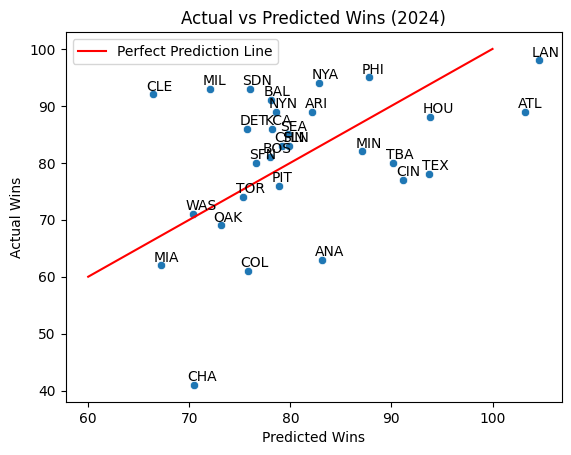

In [ ]:
avg_wins_np = np.array(avg_wins)
actual_wins_np = np.array(actual_team_wins)

sns.scatterplot(x=avg_wins_np, y=actual_wins_np)
plt.xlabel('Predicted Wins')
plt.ylabel('Actual Wins')
plt.title(f'Actual vs Predicted Wins ({season})')

# Label points
for i, team in enumerate(TEAMS):
    plt.text(x=avg_wins_np[i] - 0.7, y=actual_wins_np[i] + 0.7, s=team)
    
# Line with slope 1 (perfect)
xp = np.linspace(60,100)
yp = xp
plt.plot(xp, yp, color='red', label='Perfect Prediction Line')

plt.legend()

### r^2 Score

In [ ]:
r2_score(actual_wins_np, avg_wins_np)

-0.0036458316391780876

### r^2 Score Baseline: FanGraphs

In [ ]:
fangraphs_team_wins_map = {
    'LAN': 96,   # Dodgers
    'ATL': 93,   # Braves
    'PHI': 87,   # Phillies
    'NYN': 86,   # Mets
    'ARI': 86,   # Diamondbacks
    'NYA': 86,   # Yankees
    'BOS': 85,   # Red Sox
    'TEX': 84,   # Rangers
    'SEA': 84,   # Mariners
    'CHN': 84,   # Cubs
    'HOU': 84,   # Astros
    'BAL': 83,   # Orioles
    'MIN': 83,   # Twins
    'TOR': 83,   # Blue Jays
    'SDN': 82,   # Padres
    'DET': 82,   # Tigers
    'TBA': 82,   # Rays
    'SFN': 81,   # Giants
    'MIL': 81,   # Brewers
    'KCA': 81,   # Royals
    'SLN': 79,   # Cardinals
    'PIT': 78,   # Pirates
    'CIN': 78,   # Reds
    'CLE': 78,   # Guardians
    'ATH': 76,   # Athletics
    'ANA': 76,   # Angels
    'WAS': 73,   # Nationals
    'MIA': 71,   # Marlins
    'COL': 65,   # Rockies
    'CHA': 63    # White Sox
}



fangraphs_wins_np = np.array([fangraphs_team_wins_map[team] for team in TEAMS])

KeyError: 'OAK'

In [ ]:
r2_score(actual_wins_np, fangraphs_wins_np)

0.45967741935483875